# EOD Classification Model on Intraday Data

Applies the **EOD PCA-SVM classification model** (z-score binning into {-1, 0, +1},
PCA projection, SVM-RBF) to **intraday 30-min bar** data on
`USD-SOFR-1D-Q12STIRT` / `IMM_4xIMM_5`.

**Key adaptation — time-of-day volatility adjustment:**

Intraday volatility follows strong time-of-day patterns (quiet Asian session,
London open spike, US open violence).  A flat rolling std in the z-score
denominator creates spurious signals during dead hours and compresses real
signals during active hours.  The `tod_volatility_adjust=True` flag groups
returns by time-of-day bucket and uses expanding per-bucket volatility as the
z-score denominator.

This notebook runs three variants side by side:
1. **Flat z-score** — standard `_backward_momentum_zscore` (no TOD adjustment)
2. **TOD-adjusted z-score** — `_tod_adjusted_momentum_zscore` (expanding)
3. **TOD-adjusted z-score (rolling)** — with a lookback window

All use intraday-scaled EMA windows adapted from the Matlab `pfBBGHourlySVM`
window sizes.

In [1]:
%load_ext autoreload
%autoreload 2

import datetime
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz

sys.path.append("../../")

from BT.signals import pca_svm_momentum_signal, run_technical_indicator_query_backtest
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

NYC = pytz.timezone("America/New_York")

In [2]:
# ── Load intraday data ───────────────────────────────────────────────────
curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")
ts_builder = TimeseriesBuilder()
trade_bpv = 100_000.0

start = NYC.localize(datetime.datetime(2025, 3, 27, 18, 0))
end = NYC.localize(datetime.datetime(2026, 3, 27, 17, 0))

q = UnifiedQuery(
    curve="USD-SOFR-1D-Q12STIRT",
    tenor="IMM_4xIMM_5",
    value=UnifiedValue.IRS_RATE,
)

intraday_df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[q],
    freq="1min",
    mdps={"IRS": curve_mdp},
    ignore_cache_miss=True,
)
intraday_df = intraday_df.sort_index()

rate_series = pd.to_numeric(intraday_df.iloc[:, 0], errors="coerce").dropna()
rate_series = rate_series.resample("30min").last().dropna()
rate_series.name = "IMM_4xIMM_5"

print(f"Loaded {len(rate_series)} bars from {rate_series.index[0]} to {rate_series.index[-1]}")

DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


Loaded 11549 bars from 2025-03-27 18:00:00-04:00 to 2026-03-27 17:00:00-04:00


## Variant 1: Flat z-score (no TOD adjustment)

Standard EOD classification model applied directly to intraday bars.

In [3]:
# Intraday-scaled windows (from Matlab pfBBGHourlySVM)
EWMA_SHORT = [24, 48, 120, 240]
EWMA_LONG = [360, 1080, 1440]

# EOD classification model with flat z-score
sig_flat = pca_svm_momentum_signal(
    rate_series,
    ewma_short_spans=EWMA_SHORT,
    ewma_long_spans=EWMA_LONG,
    n_components=2,
    svm_c=0.02,
    svm_gamma=0.1,
    label_window=48,          # ~1 day of 30-min bars
    z_threshold=1.75,
    train_fraction=0.7,
    retrain_every=48,         # retrain daily
    tod_volatility_adjust=False,
)

display(sig_flat.indicator_frame.tail())

,momentum_zscore,label,decision_score,pc_1,pc_2
Date,,,,,
2026-03-27 15:00:00-04:00,-7.872410,-1.0,2.222774,-9.844465,-1.247004
2026-03-27 15:30:00-04:00,-9.440426,-1.0,2.222731,-9.741812,-1.331063
2026-03-27 16:00:00-04:00,-8.604165,-1.0,2.222654,-9.647906,-1.444133
2026-03-27 16:30:00-04:00,-7.185026,-1.0,2.222540,-9.553223,-1.579945
2026-03-27 17:00:00-04:00,-8.141142,-1.0,2.222391,-9.460203,-1.723688


## Variant 2: TOD-adjusted z-score (expanding)

Uses time-of-day volatility profile as the z-score denominator.
Expanding window over all available history per TOD bucket.

In [4]:
# EOD classification model with TOD-adjusted z-score (expanding)
sig_tod = pca_svm_momentum_signal(
    rate_series,
    ewma_short_spans=EWMA_SHORT,
    ewma_long_spans=EWMA_LONG,
    n_components=2,
    svm_c=0.02,
    svm_gamma=0.1,
    label_window=48,
    z_threshold=1.75,
    train_fraction=0.7,
    retrain_every=48,
    tod_volatility_adjust=True,
    tod_volatility_lookback=None,  # expanding
)

display(sig_tod.indicator_frame.tail())

,momentum_zscore,label,decision_score,pc_1,pc_2
Date,,,,,
2026-03-27 15:00:00-04:00,-10.264708,-1.0,2.223420,-9.844465,-1.247004
2026-03-27 15:30:00-04:00,-16.421007,-1.0,2.223477,-9.741812,-1.331063
2026-03-27 16:00:00-04:00,-11.109071,-1.0,2.223466,-9.647906,-1.444133
2026-03-27 16:30:00-04:00,-13.056865,-1.0,2.223382,-9.553223,-1.579945
2026-03-27 17:00:00-04:00,-364.808575,-1.0,2.223219,-9.460203,-1.723688


## Variant 3: TOD-adjusted z-score (rolling 20-day lookback)

Same TOD adjustment but with a rolling 20-day lookback per bucket,
so the vol profile adapts to regime changes.

In [5]:
# EOD classification model with TOD-adjusted z-score (rolling 20-day)
sig_tod_rolling = pca_svm_momentum_signal(
    rate_series,
    ewma_short_spans=EWMA_SHORT,
    ewma_long_spans=EWMA_LONG,
    n_components=2,
    svm_c=0.02,
    svm_gamma=0.1,
    label_window=48,
    z_threshold=1.75,
    train_fraction=0.7,
    retrain_every=48,
    tod_volatility_adjust=True,
    tod_volatility_lookback=20,  # rolling 20 same-TOD observations
)

display(sig_tod_rolling.indicator_frame.tail())

,momentum_zscore,label,decision_score,pc_1,pc_2
Date,,,,,
2026-03-27 15:00:00-04:00,-5.879776,-1.0,2.222862,-9.866610,-1.227146
2026-03-27 15:30:00-04:00,-16.053519,-1.0,2.222902,-9.763958,-1.311437
2026-03-27 16:00:00-04:00,-7.269661,-1.0,2.222892,-9.670426,-1.425648
2026-03-27 16:30:00-04:00,-10.342540,-1.0,2.222829,-9.576391,-1.563093
2026-03-27 17:00:00-04:00,-5273.505859,-1.0,2.222714,-9.484071,-1.708685


## Vectorized PnL comparison

In [6]:
def vectorized_pnl(sig, rate_series, trade_bpv=100_000.0, cost_bps=0.25):
    """Quick vectorized PnL from a signal result."""
    position = sig.execution_position.fillna(0.0)
    delta = rate_series.diff().fillna(0.0)
    gross_pnl = -position * delta * trade_bpv * 100.0

    trade_sides = position.diff().abs()
    trade_sides.iloc[0] = abs(position.iloc[0])
    costs = trade_sides * cost_bps * trade_bpv
    net_pnl = gross_pnl - costs
    cumulative = net_pnl.cumsum()

    std = float(net_pnl.std())
    ann_factor = 48 * 252
    sharpe = float(net_pnl.mean() / std * np.sqrt(ann_factor)) if std > 0 else 0.0
    drawdown = cumulative - cumulative.cummax()

    nonzero = net_pnl[net_pnl != 0.0]
    win_rate = float((nonzero > 0).mean()) if len(nonzero) else 0.0

    return {
        "total_pnl": float(cumulative.iloc[-1]),
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "n_trades": float(trade_sides.sum()),
        "win_rate": win_rate,
        "cumulative": cumulative,
    }


variants = {
    "Flat z-score": sig_flat,
    "TOD-adjusted (expanding)": sig_tod,
    "TOD-adjusted (rolling 20d)": sig_tod_rolling,
}

metrics_rows = []
cumulative_curves = {}
for name, sig in variants.items():
    m = vectorized_pnl(sig, rate_series, trade_bpv=trade_bpv)
    metrics_rows.append({"variant": name, **{k: v for k, v in m.items() if k != "cumulative"}})
    cumulative_curves[name] = m["cumulative"]

metrics_df = pd.DataFrame(metrics_rows).set_index("variant")
display(metrics_df.style.format({
    "total_pnl": "${:,.0f}",
    "sharpe": "{:.2f}",
    "max_drawdown": "${:,.0f}",
    "n_trades": "{:.0f}",
    "win_rate": "{:.1%}",
}).background_gradient(subset=["sharpe"], cmap="RdYlGn"))

,total_pnl,sharpe,max_drawdown,n_trades,win_rate
variant,,,,,
Flat z-score,"$-2,647,987",-0.51,"$-5,227,338",31,48.9%
TOD-adjusted (expanding),"$-2,093,470",-0.42,"$-5,781,504",25,49.0%
TOD-adjusted (rolling 20d),"$-2,391,226",-0.46,"$-4,900,384",119,48.2%


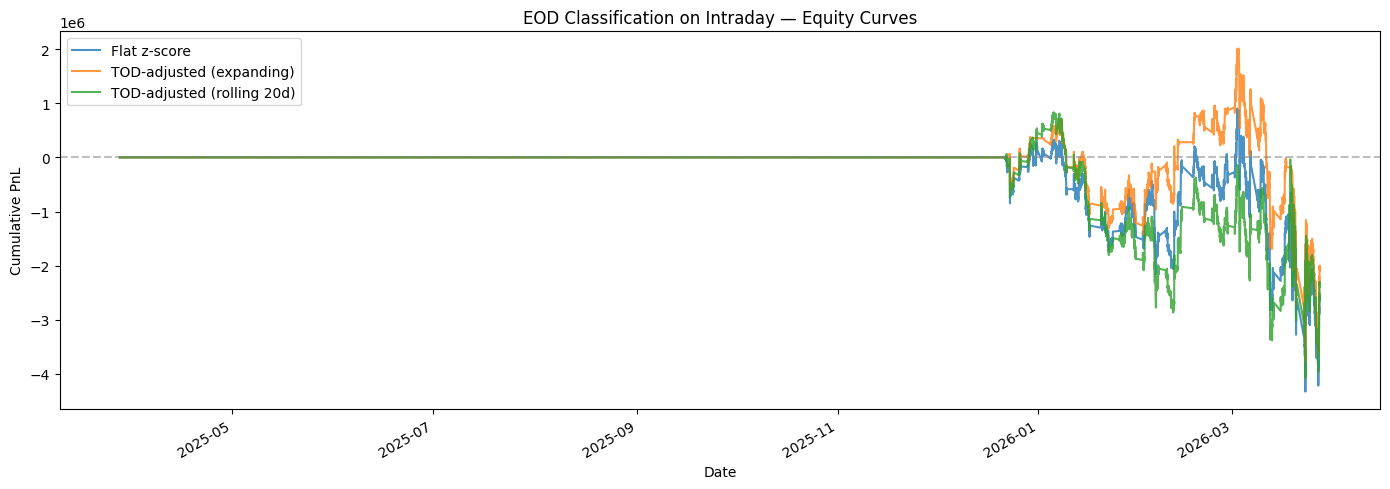

In [7]:
# ── Equity curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for name, curve in cumulative_curves.items():
    curve.plot(ax=ax, label=name, alpha=0.8)
ax.set_title("EOD Classification on Intraday — Equity Curves")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

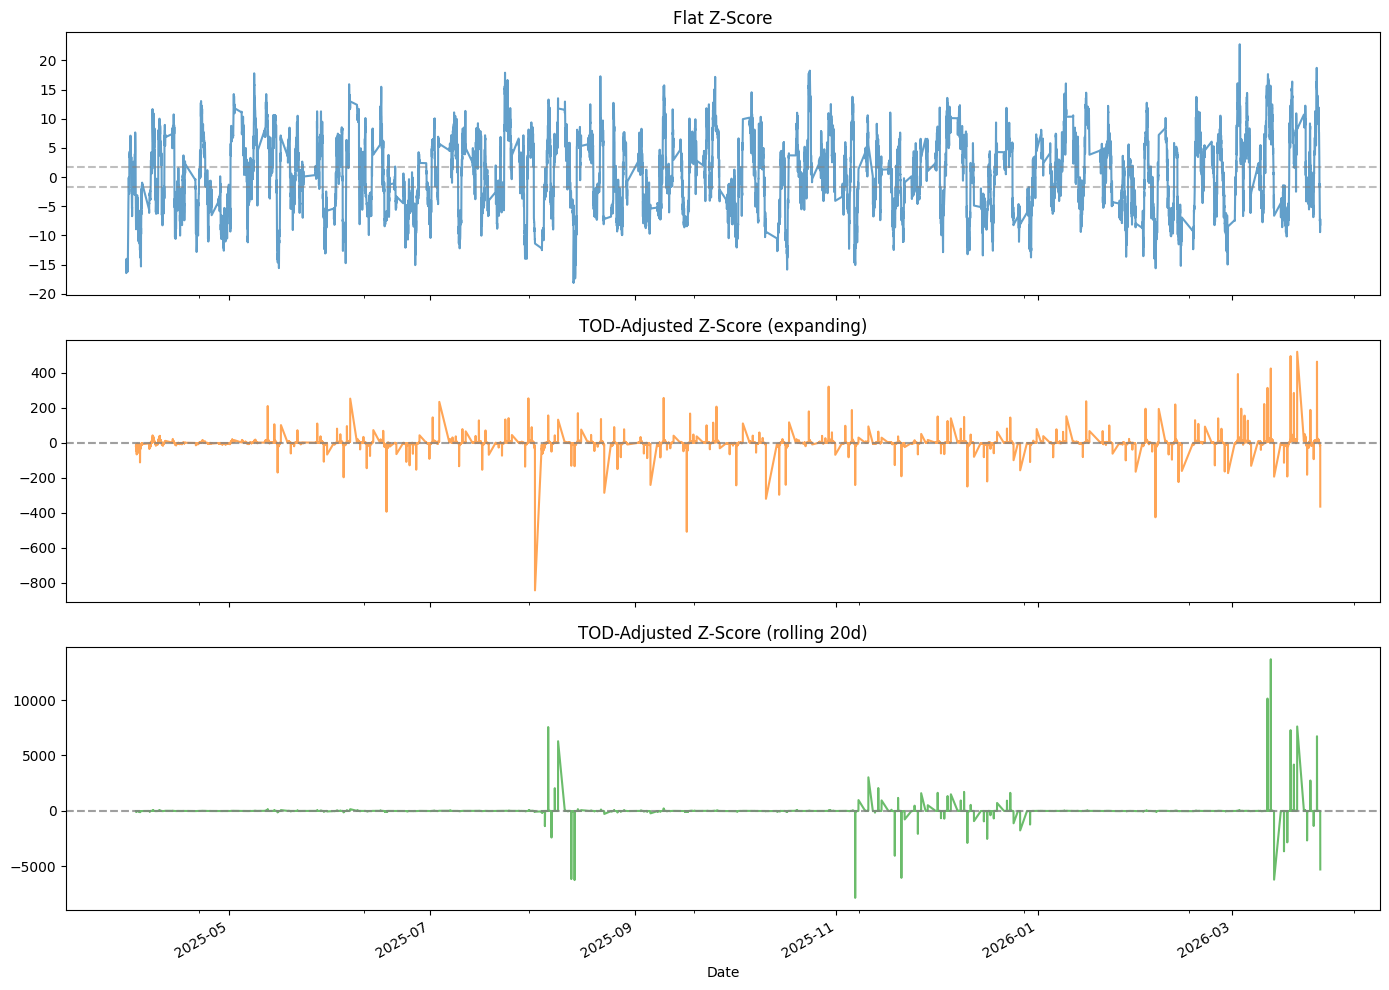

In [8]:
# ── Z-score comparison: flat vs TOD-adjusted ─────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

sig_flat.indicator_frame["momentum_zscore"].dropna().plot(
    ax=axes[0], title="Flat Z-Score", color="tab:blue", alpha=0.7,
)
axes[0].axhline(1.75, color="gray", linestyle="--", alpha=0.5)
axes[0].axhline(-1.75, color="gray", linestyle="--", alpha=0.5)

sig_tod.indicator_frame["momentum_zscore"].dropna().plot(
    ax=axes[1], title="TOD-Adjusted Z-Score (expanding)", color="tab:orange", alpha=0.7,
)
axes[1].axhline(1.75, color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(-1.75, color="gray", linestyle="--", alpha=0.5)

sig_tod_rolling.indicator_frame["momentum_zscore"].dropna().plot(
    ax=axes[2], title="TOD-Adjusted Z-Score (rolling 20d)", color="tab:green", alpha=0.7,
)
axes[2].axhline(1.75, color="gray", linestyle="--", alpha=0.5)
axes[2].axhline(-1.75, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Best variant: TOD-adjusted (expanding) (Sharpe=-0.42)


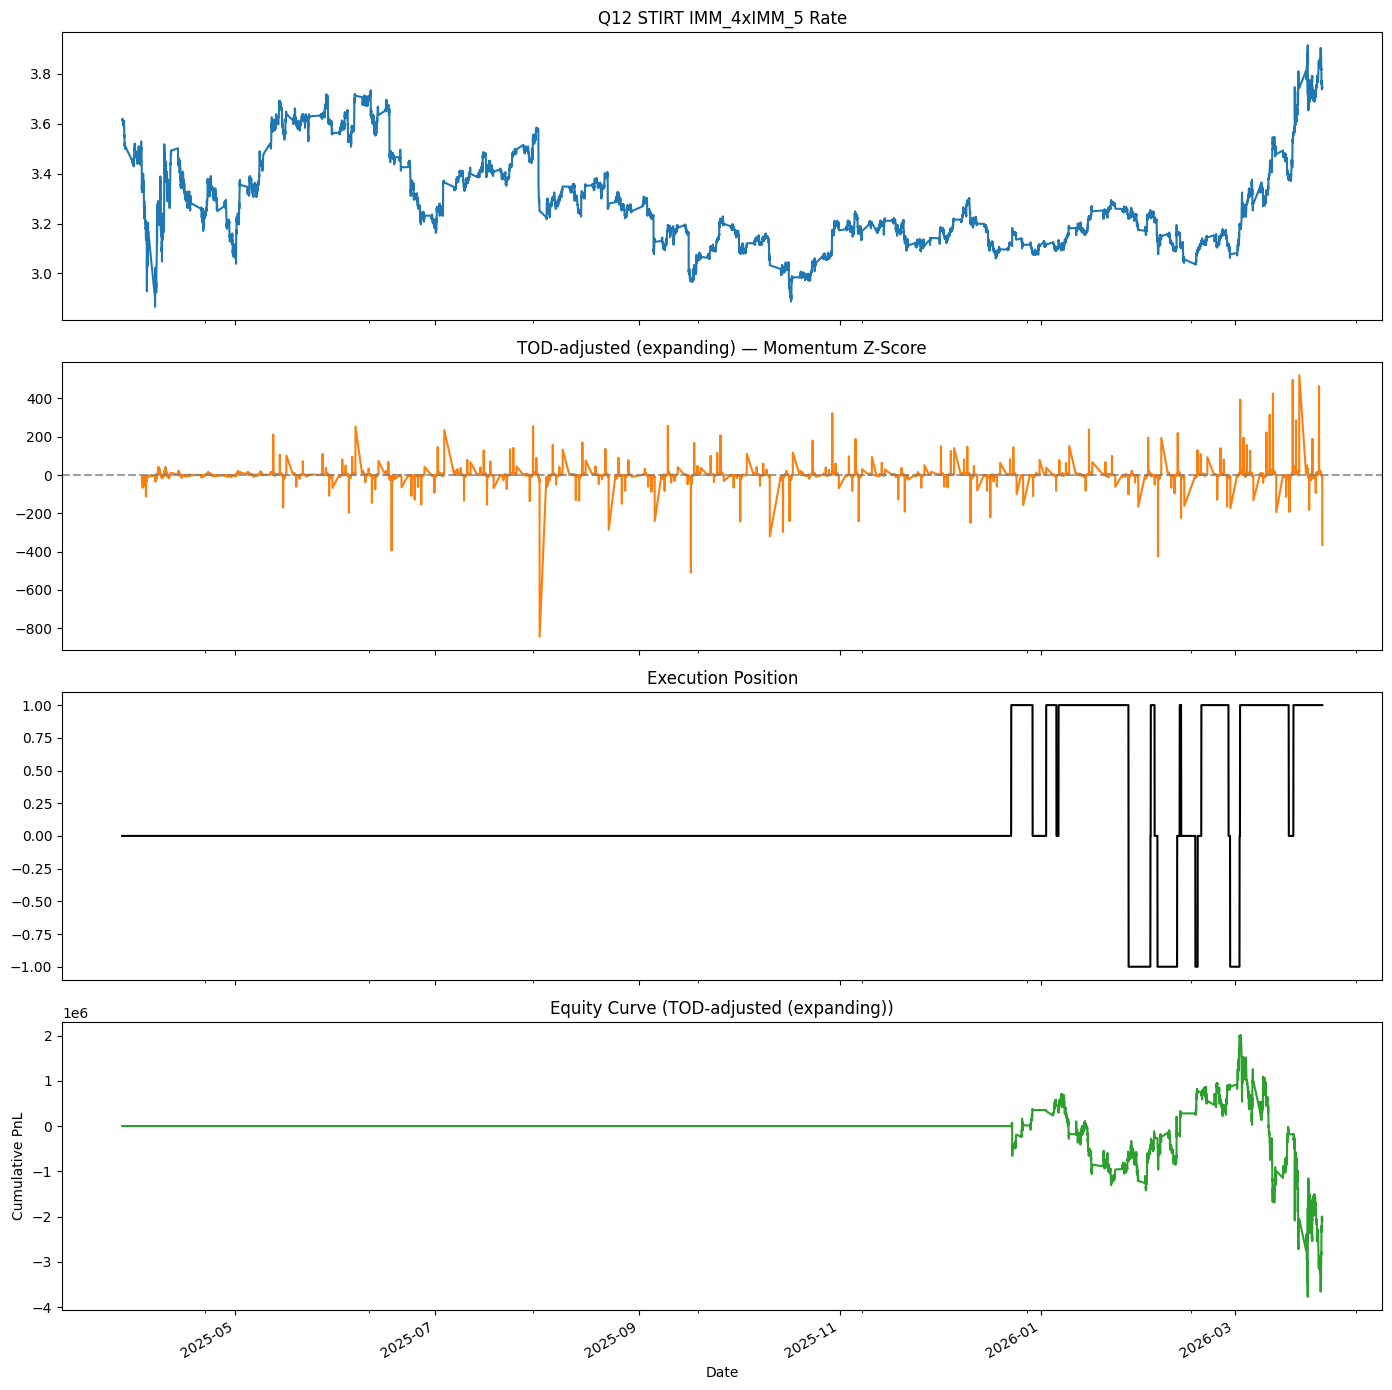

In [9]:
# ── Position and rate panels for the best TOD variant ────────────────────
# Pick the variant with the highest Sharpe for the detailed view
best_name = metrics_df["sharpe"].idxmax()
best_sig = variants[best_name]
best_curve = cumulative_curves[best_name]
print(f"Best variant: {best_name} (Sharpe={metrics_df.loc[best_name, 'sharpe']:.2f})")

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
rate_series.plot(ax=axes[0], title="Q12 STIRT IMM_4xIMM_5 Rate")
best_sig.indicator_frame["momentum_zscore"].dropna().plot(
    ax=axes[1], title=f"{best_name} — Momentum Z-Score", color="tab:orange",
)
axes[1].axhline(1.75, color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(-1.75, color="gray", linestyle="--", alpha=0.5)
best_sig.execution_position.fillna(0.0).plot(
    ax=axes[2], title="Execution Position", color="black",
)
best_curve.plot(ax=axes[3], title=f"Equity Curve ({best_name})", color="tab:green")
axes[3].set_ylabel("Cumulative PnL")
plt.tight_layout()
plt.show()

## Query-driven backtest (best variant)

In [10]:
def trade_query_factory(target_position, now, info):
    _ = now, info
    return IRSwapQuery(
        curve="USD-SOFR-1D-Q12STIRT",
        tenor="IMM_4xIMM_5",
        value=IRSwapValue.NPV,
        market_request={"timestamp": "now"},
        structure_kwargs={"bpv": trade_bpv * float(target_position)},
        tags=("intraday_eod_pca_svm_momentum_q12stirt",),
    )


query_backtest = run_technical_indicator_query_backtest(
    best_sig,
    trade_query_factory=trade_query_factory,
    mdp=curve_mdp,
    strategy_name="intraday_eod_pca_svm_momentum_q12stirt",
    ignore_cache_miss=True,
    show_progress=True,
)

query_backtest.metrics

INTRADAY_EOD_PCA_SVM_MOMENTUM_Q12STIRT QUERY BT: 100%|██████████| 11549/11549 [01:13<00:00, 156.63step/s]


{'total_pnl': -2086540.549193509,
 'sharpe': -0.30245791909285047,
 'max_drawdown': -6291185.616824206,
 'trade_sides': 13.0}

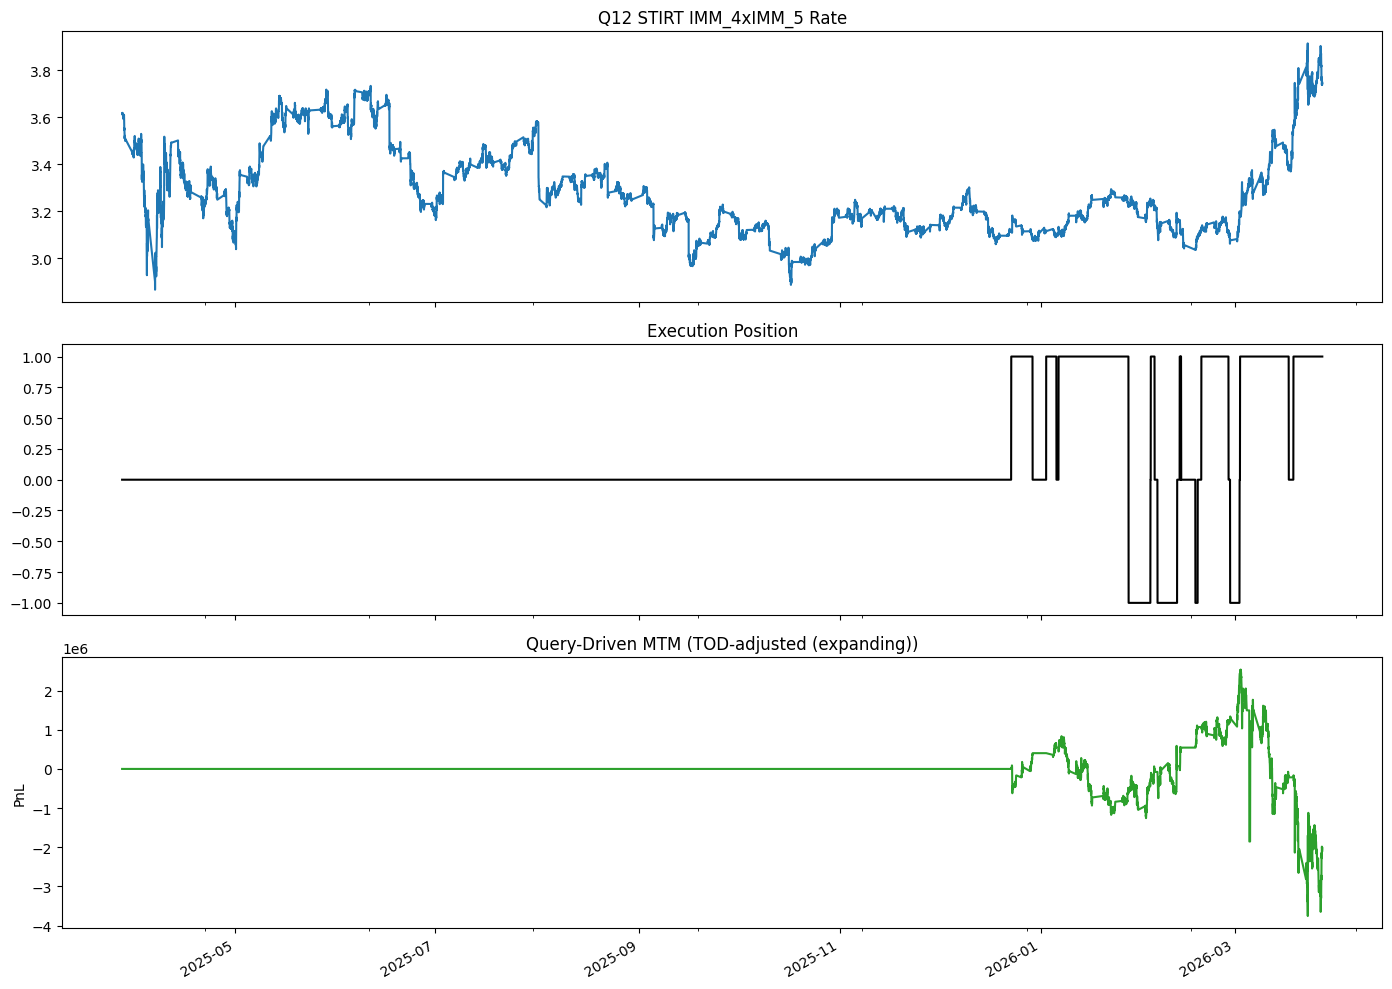

,timestamp,signal_key,raw_signal_key,position_id,signal_direction,order_type
8,2026-02-17 01:30:00-05:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-02-17T01:30:00-05:00|9|leg1,-1,QueryOrder
9,2026-02-18 21:00:00-05:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-02-18T21:00:00-05:00|10|leg1,1,QueryOrder
10,2026-02-27 15:00:00-05:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-02-27T15:00:00-05:00|11|leg1,-1,QueryOrder
11,2026-03-02 15:30:00-05:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-03-02T15:30:00-05:00|12|leg1,1,QueryOrder
12,2026-03-18 22:00:00-04:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-03-18T22:00:00-04:00|13|leg1,1,QueryOrder


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
rate_series.plot(ax=axes[0], title="Q12 STIRT IMM_4xIMM_5 Rate")
best_sig.execution_position.fillna(0.0).plot(
    ax=axes[1], title="Execution Position", color="black",
)
query_backtest.mtm_history.plot(
    ax=axes[2], title=f"Query-Driven MTM ({best_name})", color="tab:green",
)
axes[2].set_ylabel("PnL")
plt.tight_layout()
plt.show()

query_backtest.order_frame.tail()